[![session-10](https://github.com/cvail-research/Hands-on-Computer-Vision/blob/main/sesiones/sesion10/Sesion10_banner.png?raw=1)](https://github.com/semilleroCV/Hands-on-Computer-Vision/tree/main/sesiones/sesion10)

# <font color="EB9A54"><center> **Hands-on Sesión 10: De imágenes térmicas espectrales a estimación de profundidad 📚🌡️** </center></font>

En este notebook veremos que una imagen térmica es una modalidad más de visión por computadora. Al igual que una imagen espectral, cada píxel contiene una firma a varias longitudes de onda; y, al igual que en estimación de profundidad, utilizaremos esas mediciones para inferir propiedades de la escena.

Partiremos de la medición producida por el modelo directo del notebook anterior y recorreremos el camino inverso: ajustaremos los parámetros de la escena mediante descenso por gradiente.

## <font color='#4C5FDA'> **Contenido**</font>

[**1. Cargar y visualizar la escena**](#tema1)

[**2. Simular la imagen térmica espectral**](#tema2)

[**3. Formular el problema inverso**](#tema3)

[**4. Optimizar los parámetros de la escena**](#tema4)

[**5. Evaluar la profundidad estimada**](#tema5)

[**6. Analizar la temperatura y la emisividad espectral**](#tema6)

# <font color="4C5FDA"> **1. Cargar y visualizar la escena** </font><a id="tema1"></a>

Usaremos los mismos datos del notebook anterior. Para que la optimización sea rápida, tomaremos una muestra espacial regular de la escena, pero conservaremos sus 49 bandas espectrales.

In [19]:
#@title **Cargar librerías y descargar los datos**
%matplotlib inline

from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c, h, k

folder_id = "1d150jOzFGBY0eea_Ak1kgLSU70OnwaC7"
data_dir = Path("data")
required_files = [
    "depth.npy",
    "emap.npy",
    "emissivity.npy",
    "matName_FullDatabase.npy",
    "scene.png",
    "tmap.npy",
    "wavelengths.npy",
    "atmospheres/enclosure.txt",
]

if not all((data_dir / filename).exists() for filename in required_files):
    gdown.download_folder(id=folder_id, output="./", quiet=False)

missing_files = [filename for filename in required_files if not (data_dir / filename).exists()]
if missing_files:
    raise FileNotFoundError(f"La descarga está incompleta. Faltan: {missing_files}")

print(f"Datos disponibles en: {data_dir}")

Datos disponibles en: data


In [20]:
#@title **Cargar una muestra espacial de la escena**
spatial_stride = 10

wavelengths = np.load(data_dir / "wavelengths.npy").astype(np.float32)
depth_truth = np.load(data_dir / "depth.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride
].astype(np.float32)
temperature_truth_c = np.load(data_dir / "tmap.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride
].astype(np.float32)
material_map = np.load(data_dir / "emap.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride
].astype(np.int32)
emissivity_truth = np.load(data_dir / "emissivity.npy", mmap_mode="r")[
    ::spatial_stride, ::spatial_stride, :
].astype(np.float32)

raw_names = np.load(
    data_dir / "matName_FullDatabase.npy", allow_pickle=True
).item()["matName"]
material_names = np.hstack(raw_names.squeeze())

assert emissivity_truth.shape == (*depth_truth.shape, len(wavelengths))
assert depth_truth.shape == temperature_truth_c.shape == material_map.shape

# El identificador 0 corresponde al cielo. Lo excluiremos del problema inverso:
# su profundidad está saturada en 100 m y no representa un objeto finito.
object_mask = material_map != 0

print(f"Muestra espacial: {depth_truth.shape[1]} × {depth_truth.shape[0]} píxeles")
print(f"Bandas espectrales: {len(wavelengths)}")
print(f"Píxeles de objetos usados: {object_mask.sum()}")

Muestra espacial: 192 × 108 píxeles
Bandas espectrales: 49
Píxeles de objetos usados: 19867


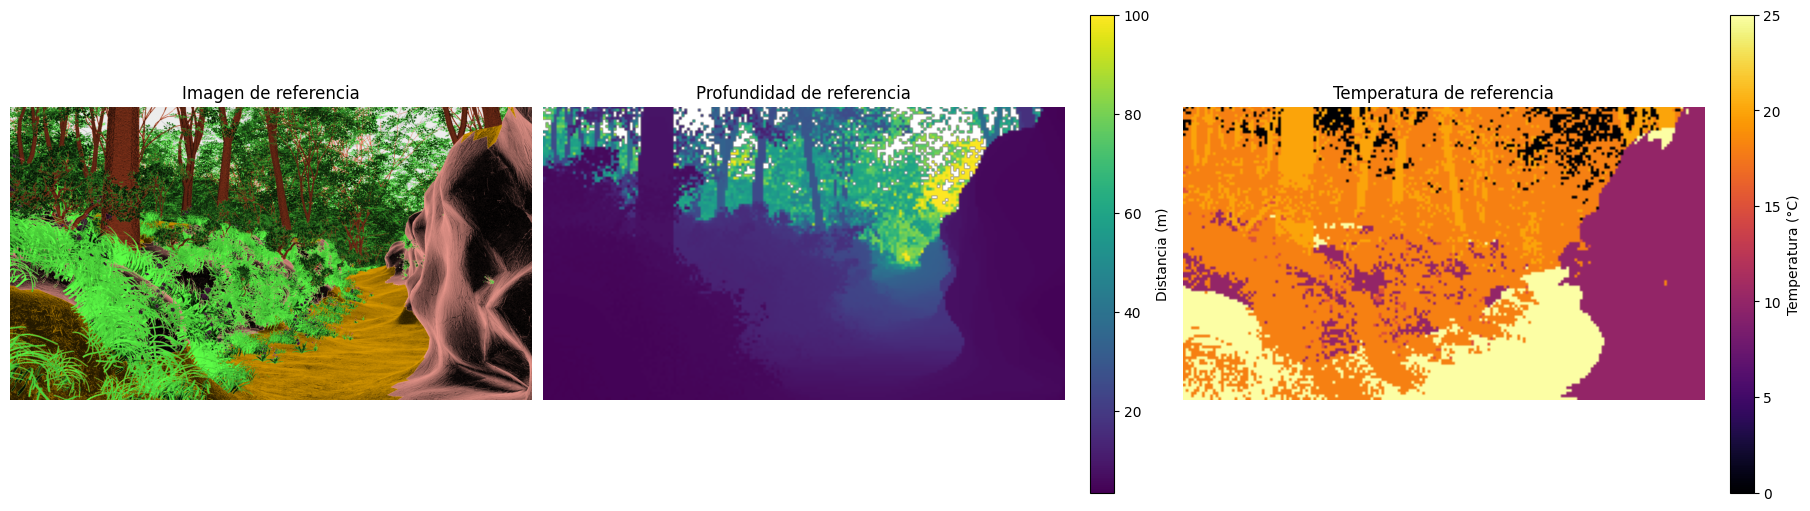

In [21]:
#@title **Visualizar la escena de referencia**
scene_reference = plt.imread(data_dir / "scene.png")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes[0].imshow(scene_reference)
axes[0].set_title("Imagen de referencia")
axes[0].axis("off")

depth_image = axes[1].imshow(np.where(object_mask, depth_truth, np.nan), cmap="viridis")
axes[1].set_title("Profundidad de referencia")
axes[1].axis("off")
fig.colorbar(depth_image, ax=axes[1], label="Distancia (m)")

temperature_image = axes[2].imshow(temperature_truth_c, cmap="inferno")
axes[2].set_title("Temperatura de referencia")
axes[2].axis("off")
fig.colorbar(temperature_image, ax=axes[2], label="Temperatura (°C)")
plt.show()

# <font color="4C5FDA"> **2. Simular la imagen térmica espectral** </font><a id="tema2"></a>

Como los notebooks no comparten automáticamente sus variables, reconstruiremos aquí una muestra pequeña de esa misma medición antes de ejecutar únicamente el backward.

El resultado final del notebook anterior puede escribirse, para cada píxel, como

$$
L_{\mathrm{sensor}}(\lambda)
=\tau(\lambda,d)\,\varepsilon(\lambda)B(\lambda;T_{\mathrm{object}})
+[1-\tau(\lambda,d)]B(\lambda;T_{\mathrm{air}})+n(\lambda).
$$

La atmósfera y su temperatura se consideran conocidas. La distancia $d$, la temperatura del objeto y su emisividad espectral serán las incógnitas del problema inverso.

In [22]:
def blackbody(temperature_k):
    # Radiancia de cuerpo negro para todos los píxeles y bandas.
    wavelength_m = wavelengths[None, :] * 1e-6
    temperature_k = np.asarray(temperature_k, dtype=np.float32).reshape(-1, 1)
    exponent = h * c / (wavelength_m * k * temperature_k)
    radiance = (2 * h * c**2) / (wavelength_m**5 * np.expm1(exponent))
    return (radiance * 1e-4).astype(np.float32)


def d_blackbody_d_temperature(temperature_k):
    # Derivada analítica de B(lambda; T) respecto a T.
    wavelength_m = wavelengths[None, :] * 1e-6
    temperature_k = np.asarray(temperature_k, dtype=np.float32).reshape(-1, 1)
    exponent = h * c / (wavelength_m * k * temperature_k)
    exp_exponent = np.exp(exponent)
    scale = (2 * h * c**2) / wavelength_m**5 * 1e-4
    derivative = (
        scale
        * exp_exponent
        * exponent
        / (temperature_k * (exp_exponent - 1) ** 2)
    )
    return derivative.astype(np.float32)


atmosphere_table = np.loadtxt(data_dir / "atmospheres" / "enclosure.txt")
attenuation_db = np.interp(
    wavelengths, atmosphere_table[:, 0], atmosphere_table[:, 2]
).astype(np.float32)


def transmittance(depth_m):
    # Transmitancia de la envolvente para cada distancia y banda.
    depth_m = np.asarray(depth_m, dtype=np.float32).reshape(-1, 1)
    return (10 ** (-depth_m * attenuation_db[None, :] / 10)).astype(np.float32)

## <font color='#ECA702'>**<font color="#FF0000">R</font><font color="#FF7F00">e</font><font color="#FFFF00">t</font><font color="#00FF00">o</font> #<font color="#0000FF">1</font>** 💪</font>

Completa la ecuación de `clean_radiance`: identifica los factores de la radiancia emitida por el objeto que atraviesa la atmósfera y los factores de la emisión atmosférica. El ruido del sensor se agregará después.

In [23]:
#@title **Reproducir la medición ruidosa del sensor**
height, width = depth_truth.shape
depth_vector = depth_truth.reshape(-1)
temperature_vector_k = temperature_truth_c.reshape(-1) + 273.15
emissivity_matrix = emissivity_truth.reshape(-1, len(wavelengths))

air_temperature_k = 288.0
air_blackbody = blackbody([air_temperature_k])[0]
object_blackbody = blackbody(temperature_vector_k)
transmittance_matrix = transmittance(depth_vector)

clean_radiance = (
    transmittance_matrix * emissivity_matrix * object_blackbody
    + (1 - transmittance_matrix) * air_blackbody
)

noise_fraction = 0.01
noise_std = noise_fraction * np.percentile(clean_radiance, 99)
rng = np.random.default_rng(314)
sensor_radiance = clean_radiance + rng.normal(
    0, noise_std, size=clean_radiance.shape
).astype(np.float32)
sensor_cube = sensor_radiance.reshape(height, width, -1)

print(f"Imagen térmica espectral medida: {sensor_cube.shape}")
print(f"Desviación estándar del ruido: {noise_std:.4f} µW/(cm²·sr·µm)")

Imagen térmica espectral medida: (108, 192, 49)
Desviación estándar del ruido: 8.2730 µW/(cm²·sr·µm)


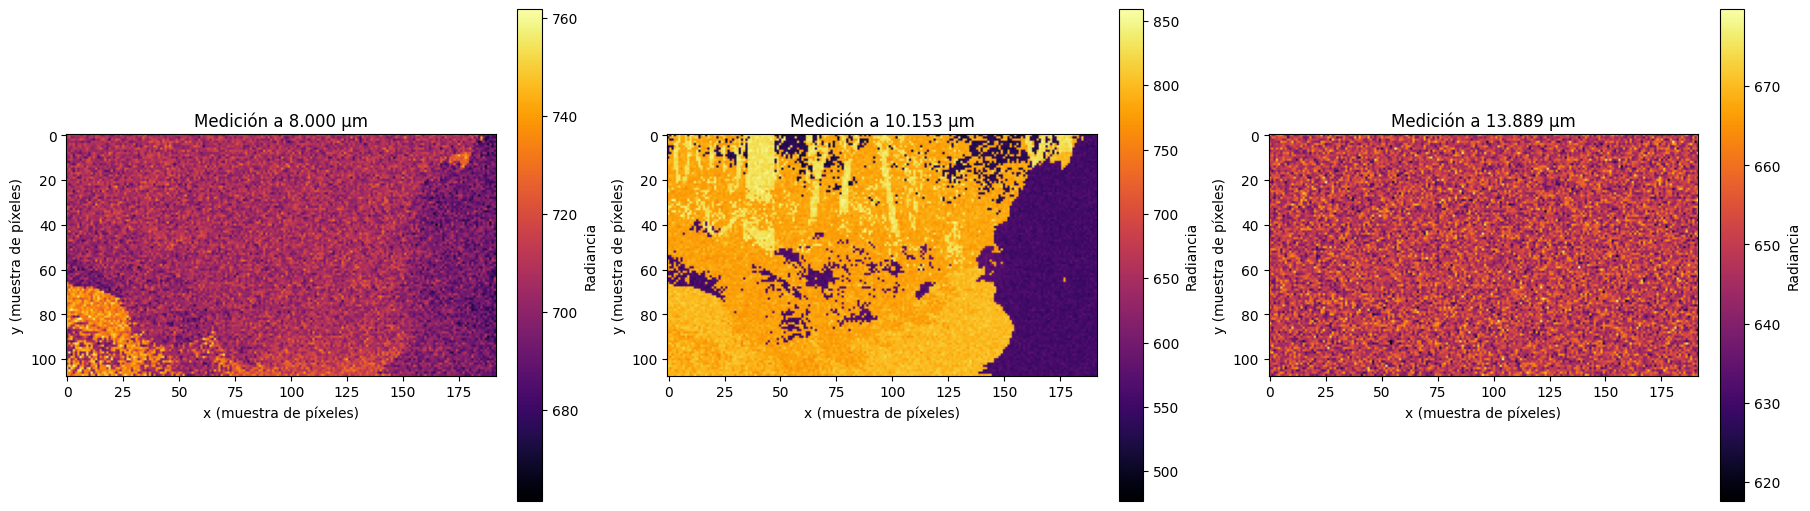

In [24]:
#@title **Visualizar bandas de la imagen térmica espectral**
band_indices = [0, len(wavelengths) // 2, len(wavelengths) - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for axis, band in zip(axes, band_indices):
    image = axis.imshow(sensor_cube[:, :, band], cmap="inferno")
    axis.set_title(f"Medición a {wavelengths[band]:.3f} µm")
    axis.set_xlabel("x (muestra de píxeles)")
    axis.set_ylabel("y (muestra de píxeles)")
    fig.colorbar(image, ax=axis, label="Radiancia")

plt.show()

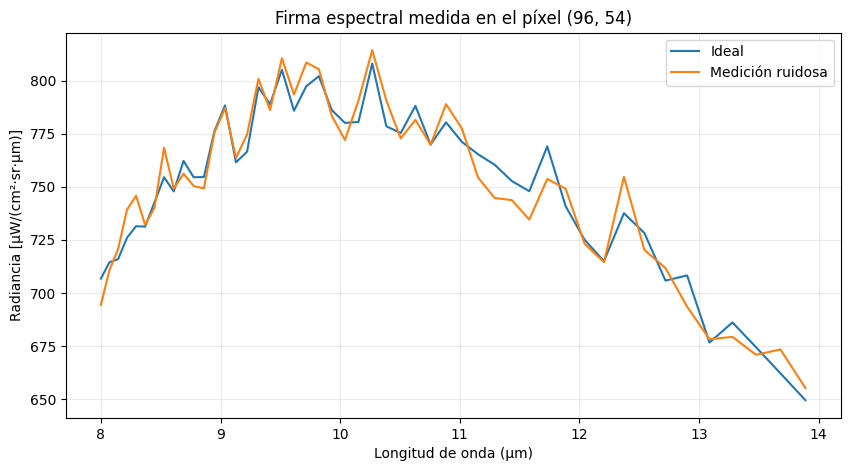

In [25]:
#@title **Examinar la medición espectral de un píxel**
pixel_y, pixel_x = 54, 96

plt.figure(figsize=(10, 5))
plt.plot(wavelengths, clean_radiance.reshape(height, width, -1)[pixel_y, pixel_x], label="Ideal")
plt.plot(wavelengths, sensor_cube[pixel_y, pixel_x], label="Medición ruidosa", linewidth=1.5)
plt.xlabel("Longitud de onda (µm)")
plt.ylabel("Radiancia [µW/(cm²·sr·µm)]")
plt.title(f"Firma espectral medida en el píxel ({pixel_x}, {pixel_y})")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# <font color="4C5FDA"> **3. Formular el problema inverso** </font><a id="tema3"></a>

Buscaremos la distancia, la temperatura del objeto y una emisividad independiente para cada banda espectral. El primer término de la función de costo mide el error entre la medición y la predicción del modelo:

$$
\mathcal{L}_{\mathrm{data}}=\frac{1}{N_{\lambda}}\sum_{b=1}^{N_{\lambda}}
\left(\frac{\widehat L_{\mathrm{sensor}}(\lambda)-L_{\mathrm{sensor}}(\lambda)}{s}\right)^2.
$$

Cada píxel tiene 51 incógnitas —distancia, temperatura y 49 emisividades— pero solo 49 mediciones. Para estabilizar este problema agregaremos una **regularización de Tikhonov de primer orden**. En palabras simples, penalizaremos los cambios abruptos entre bandas vecinas para favorecer una emisividad espectral suave:

$$
\mathcal{L}_{\mathrm{smooth}}=\frac{1}{N_{\lambda}-1}\sum_{b=1}^{N_{\lambda}-1}
\left[\varepsilon(\lambda_{b+1})-\varepsilon(\lambda_b)\right]^2.
$$

La función de costo completa será

$$
\mathcal{L}_{\mathrm{total}}=\mathcal{L}_{\mathrm{data}}+\beta\mathcal{L}_{\mathrm{smooth}},
$$

donde $\beta$ controla cuánto valoramos la suavidad. La regularización no obliga a que todas las bandas tengan la misma emisividad; solamente hace costosos los saltos grandes entre bandas consecutivas.

El siguiente ejemplo usa **cinco bandas ficticias** para ilustrar esta idea. Sus índices y valores de emisividad son didácticos y no corresponden a bandas específicas del sensor.

Diferencias con salto: [ 0.02  0.13 -0.12  0.01]
Penalización con salto: 0.00795
Diferencias suaves: [ 0.02  0.02 -0.01  0.01]
Penalización suave: 0.00025


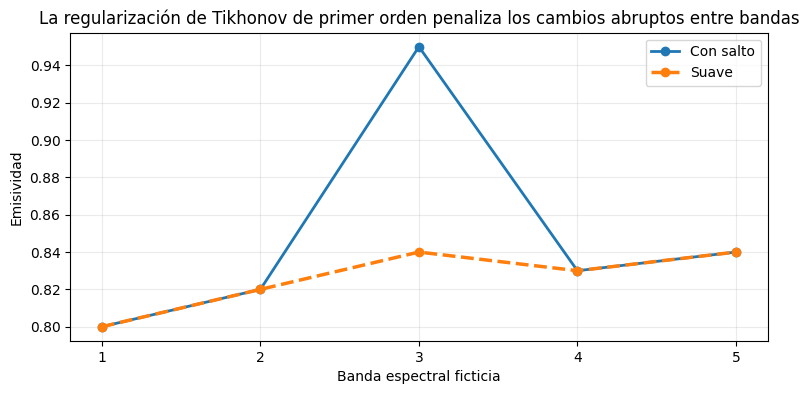

In [26]:
#@title **Entender la penalización de suavidad con un ejemplo**
emissivity_with_jump = np.array([0.80, 0.82, 0.95, 0.83, 0.84])
smooth_emissivity = np.array([0.80, 0.82, 0.84, 0.83, 0.84])

differences_with_jump = np.diff(emissivity_with_jump)
smooth_differences = np.diff(smooth_emissivity)

penalty_with_jump = np.mean(differences_with_jump**2)
smooth_penalty = np.mean(smooth_differences**2)

print("Diferencias con salto:", differences_with_jump)
print(f"Penalización con salto: {penalty_with_jump:.5f}")
print("Diferencias suaves:", smooth_differences)
print(f"Penalización suave: {smooth_penalty:.5f}")

example_bands = np.arange(1, 6)
plt.figure(figsize=(9, 4))
plt.plot(
    example_bands,
    emissivity_with_jump,
    marker="o",
    linewidth=2,
    label="Con salto",
)
plt.plot(
    example_bands,
    smooth_emissivity,
    marker="o",
    linestyle="--",
    linewidth=2.5,
    label="Suave",
)
plt.xlabel("Banda espectral ficticia")
plt.ylabel("Emisividad")
plt.title(
    "La regularización de Tikhonov de primer orden penaliza "
    "los cambios abruptos entre bandas"
)
plt.xticks(example_bands)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

Las derivadas del modelo directo son

$$
\frac{\partial \widehat L}{\partial \varepsilon}
=\tau B(\lambda;T_{\mathrm{object}}),
$$

$$
\frac{\partial \widehat L}{\partial d}
=\frac{\partial\tau}{\partial d}
\left[\varepsilon B(\lambda;T_{\mathrm{object}})-B(\lambda;T_{\mathrm{air}})\right],
\qquad
\frac{\partial\tau}{\partial d}
=-\frac{\ln(10)}{10}\alpha(\lambda)\tau,
$$

$$
\frac{\partial \widehat L}{\partial T_{\mathrm{object}}}
=\tau\varepsilon\frac{\partial B(\lambda;T_{\mathrm{object}})}{\partial T_{\mathrm{object}}}.
$$

Para una banda interna, el gradiente del término de suavidad es

$$
\frac{\partial \mathcal{L}_{\mathrm{smooth}}}{\partial \varepsilon(\lambda_b)}
=\frac{2}{N_{\lambda}-1}
\left[2\varepsilon(\lambda_b)-\varepsilon(\lambda_{b-1})-\varepsilon(\lambda_{b+1})\right].
$$

Este gradiente empuja cada emisividad hacia el promedio de sus dos vecinas. En la primera y la última banda solo existe una banda vecina. Sumaremos este gradiente al producido por el error de la radiancia. Como los parámetros tienen unidades y escalas diferentes, cada uno tendrá su propia tasa de aprendizaje. Después de cada actualización proyectaremos los valores a un intervalo físico.

# <font color="4C5FDA"> **4. Optimizar los parámetros de la escena** </font><a id="tema4"></a>

La verdad de referencia se entrega a la función únicamente para calcular métricas durante esta demostración; no participa en los gradientes ni en las actualizaciones.

## <font color='#ECA702'>**<font color="#FF0000">R</font><font color="#FF7F00">e</font><font color="#FFFF00">t</font><font color="#00FF00">o</font> #<font color="#0000FF">2</font>** 💪</font>

Completa `gradient_depth`, `gradient_temperature` y `gradient_emissivity_data`. En cada caso, multiplica `residual_factor` por la derivada correspondiente del modelo directo mostrada en la sección anterior. El gradiente de la regularización de Tikhonov se deja explícito.

In [27]:
def inverse_gradient_descent(
    observed_radiance,
    iterations=800,
    record_every=40,
    learning_rate_depth=20_000.0,
    learning_rate_temperature=20.0,
    learning_rate_emissivity=0.05,
    tikhonov_weight=1.0,
    depth_truth=None,
    temperature_truth_c=None,
    emissivity_truth=None,
):
    # Estimar distancia, temperatura y emisividad espectral por píxel.
    n_pixels, n_bands = observed_radiance.shape
    radiance_scale = np.maximum(observed_radiance.mean(axis=1, keepdims=True), 1.0)

    predicted_depth = np.full(n_pixels, 20.0, dtype=np.float32)
    predicted_temperature_k = np.full(n_pixels, 18.0 + 273.15, dtype=np.float32)
    predicted_emissivity = np.full((n_pixels, n_bands), 0.9, dtype=np.float32)

    attenuation_factor = -(np.log(10.0) / 10.0) * attenuation_db[None, :]
    history = []

    for iteration in range(iterations + 1):
        object_term = blackbody(predicted_temperature_k)
        transmission = transmittance(predicted_depth)
        prediction = air_blackbody + transmission * (
            predicted_emissivity * object_term - air_blackbody
        )

        normalized_residual = (prediction - observed_radiance) / radiance_scale

        if iteration % record_every == 0 or iteration == iterations:
            row = {
                "iteration": iteration,
                "radiance_rmse": float(np.sqrt(np.mean(normalized_residual**2))),
                "smoothness_rmse": float(
                    np.sqrt(np.mean(np.diff(predicted_emissivity, axis=1) ** 2))
                ),
            }
            if depth_truth is not None:
                row["depth_rmse"] = float(
                    np.sqrt(np.mean((predicted_depth - depth_truth) ** 2))
                )
            if temperature_truth_c is not None:
                row["temperature_rmse"] = float(
                    np.sqrt(
                        np.mean(
                            (predicted_temperature_k - 273.15 - temperature_truth_c) ** 2
                        )
                    )
                )
            if emissivity_truth is not None:
                row["emissivity_rmse"] = float(
                    np.sqrt(np.mean((predicted_emissivity - emissivity_truth) ** 2))
                )
            history.append(row)

        if iteration == iterations:
            break

        residual_factor = (
            (2.0 / n_bands)
            * (prediction - observed_radiance)
            / radiance_scale**2
        )
        gradient_depth = np.sum(
    residual_factor
    * (attenuation_factor * transmission
       * (predicted_emissivity * object_term - air_blackbody)),
    axis=1,
)
        gradient_temperature = np.sum(
    residual_factor
    * (predicted_emissivity * object_term - air_blackbody),
    axis=1,
)
        gradient_emissivity_data = residual_factor * (transmission * object_term)

        # Tikhonov de primer orden: penalizar diferencias entre bandas vecinas.
        emissivity_differences = np.diff(predicted_emissivity, axis=1)
        gradient_emissivity_smooth = np.zeros_like(predicted_emissivity)
        gradient_emissivity_smooth[:, :-1] -= emissivity_differences
        gradient_emissivity_smooth[:, 1:] += emissivity_differences
        gradient_emissivity_smooth *= 2.0 * tikhonov_weight / (n_bands - 1)
        gradient_emissivity = (
            gradient_emissivity_data + gradient_emissivity_smooth
        )

        # Regla de descenso por gradiente: theta <- theta - eta * gradiente.
        predicted_depth -= learning_rate_depth * gradient_depth
        predicted_temperature_k -= (
            learning_rate_temperature * gradient_temperature
        )
        predicted_emissivity -= learning_rate_emissivity * gradient_emissivity

        np.clip(predicted_depth, 0.0, 120.0, out=predicted_depth)
        np.clip(predicted_temperature_k, 273.15, 313.15, out=predicted_temperature_k)
        np.clip(predicted_emissivity, 0.6, 1.0, out=predicted_emissivity)

    return {
        "depth": predicted_depth,
        "temperature_c": predicted_temperature_k - 273.15,
        "emissivity": predicted_emissivity,
        "radiance": prediction,
        "history": history,
    }

In [28]:
#@title **Ejecutar el descenso por gradiente**
observed_objects = sensor_cube[object_mask]

depth_objects = depth_truth[object_mask]
temperature_objects_c = temperature_truth_c[object_mask]
emissivity_objects = emissivity_truth[object_mask]

inverse_result = inverse_gradient_descent(
    observed_objects,
    iterations=800,
    record_every=40,
    depth_truth=depth_objects,
    temperature_truth_c=temperature_objects_c,
    emissivity_truth=emissivity_objects,
)

initial_metrics = inverse_result["history"][0]
final_metrics = inverse_result["history"][-1]
print("Métricas iniciales:", initial_metrics)
print("Métricas finales:", final_metrics)

Métricas iniciales: {'iteration': 0, 'radiance_rmse': 0.08321834355592728, 'smoothness_rmse': 0.0, 'depth_rmse': 22.592103958129883, 'temperature_rmse': 4.941088676452637, 'emissivity_rmse': 0.053975071758031845}
Métricas finales: {'iteration': 800, 'radiance_rmse': 0.09565974771976471, 'smoothness_rmse': 0.026589252054691315, 'depth_rmse': 83.12852478027344, 'temperature_rmse': 20.282011032104492, 'emissivity_rmse': 0.08077966421842575}


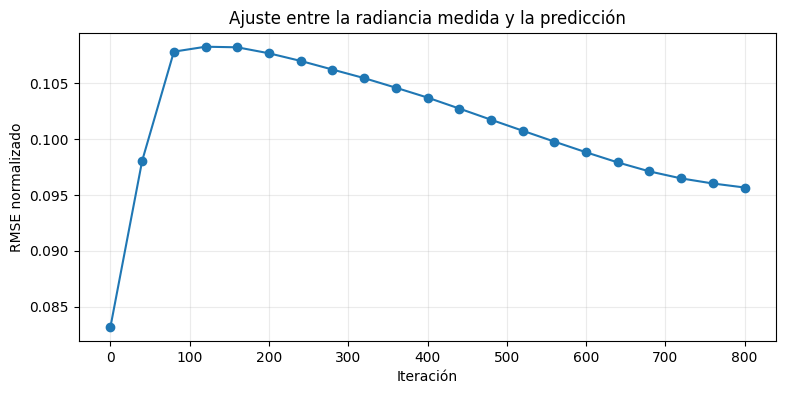

In [29]:
#@title **Visualizar la convergencia de la medición**
history = inverse_result["history"]
iterations = [row["iteration"] for row in history]

plt.figure(figsize=(9, 4))
plt.plot(iterations, [row["radiance_rmse"] for row in history], marker="o")
plt.xlabel("Iteración")
plt.ylabel("RMSE normalizado")
plt.title("Ajuste entre la radiancia medida y la predicción")
plt.grid(alpha=0.25)
plt.show()

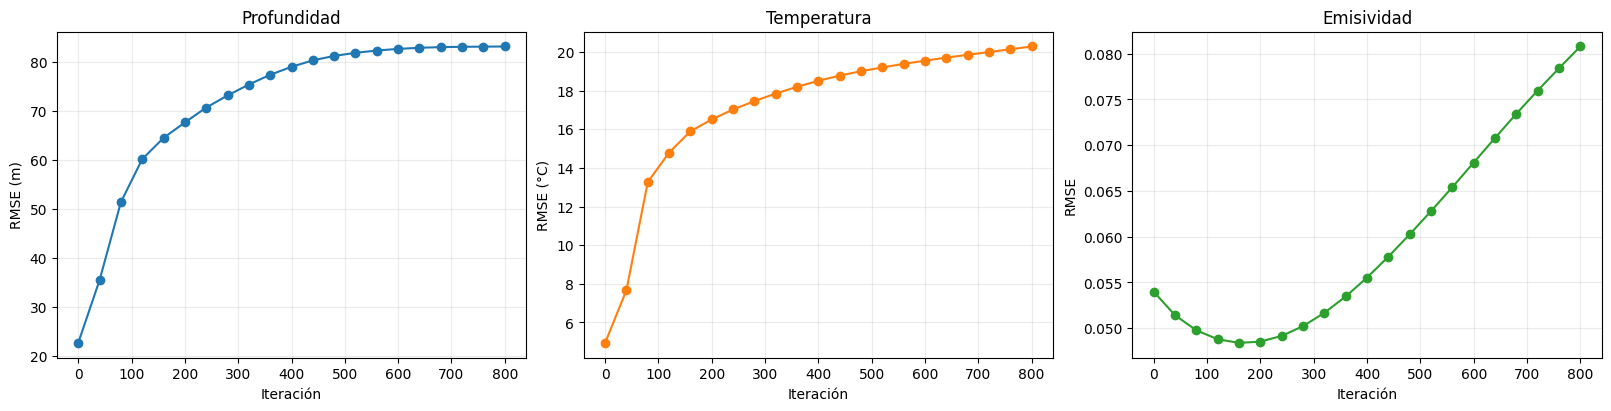

In [30]:
#@title **Comparar los errores de los parámetros estimados**
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
metrics = [
    ("depth_rmse", "Profundidad", "RMSE (m)", "tab:blue"),
    ("temperature_rmse", "Temperatura", "RMSE (°C)", "tab:orange"),
    ("emissivity_rmse", "Emisividad", "RMSE", "tab:green"),
]

for axis, (key, title, ylabel, color) in zip(axes, metrics):
    axis.plot(iterations, [row[key] for row in history], marker="o", color=color)
    axis.set_title(title)
    axis.set_xlabel("Iteración")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)

plt.show()

# <font color="4C5FDA"> **5. Evaluar la profundidad estimada** </font><a id="tema5"></a>

Reconstruiremos el mapa con la misma geometría de la muestra espacial. El cielo se deja en blanco porque no fue parte de la optimización.

## <font color='#ECA702'>**<font color="#FF0000">R</font><font color="#FF7F00">e</font><font color="#FFFF00">t</font><font color="#00FF00">o</font> #<font color="#0000FF">3</font> · Parte 1** 💪</font>

Completa `depth_error` como el error absoluto entre la profundidad estimada y la profundidad de referencia. Así, cada píxel del mapa de **Error absoluto** indicará cuántos metros separan ambas profundidades, sin importar el signo de la diferencia.

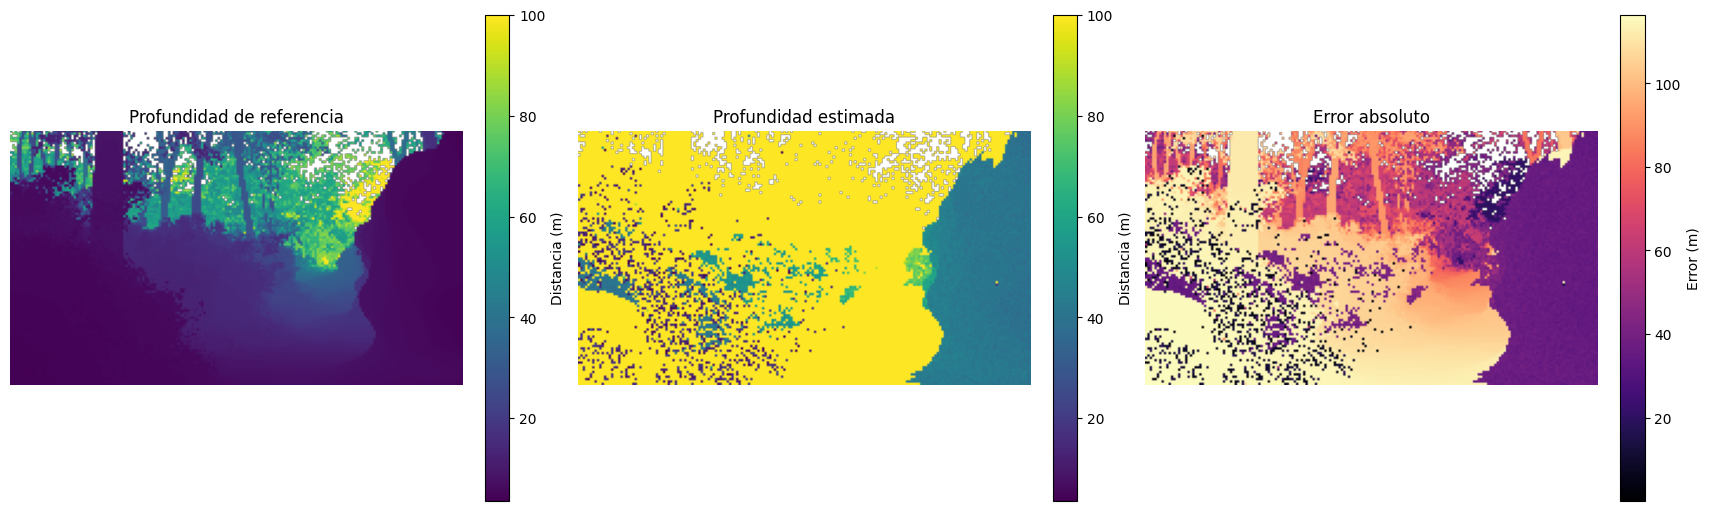

In [33]:
#@title **Comparar la profundidad de referencia y la estimada**
depth_prediction = np.full(depth_truth.shape, np.nan, dtype=np.float32)
depth_prediction[object_mask] = inverse_result["depth"]
depth_error = np.abs(depth_prediction - depth_truth)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
vmin = float(np.nanmin(depth_truth[object_mask]))
vmax = float(np.nanmax(depth_truth[object_mask]))

truth_image = axes[0].imshow(
    np.where(object_mask, depth_truth, np.nan), cmap="viridis", vmin=vmin, vmax=vmax
)
axes[0].set_title("Profundidad de referencia")
axes[0].axis("off")
fig.colorbar(truth_image, ax=axes[0], label="Distancia (m)")

prediction_image = axes[1].imshow(depth_prediction, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Profundidad estimada")
axes[1].axis("off")
fig.colorbar(prediction_image, ax=axes[1], label="Distancia (m)")

error_image = axes[2].imshow(depth_error, cmap="magma")
axes[2].set_title("Error absoluto")
axes[2].axis("off")
fig.colorbar(error_image, ax=axes[2], label="Error (m)")
plt.show()

# <font color="4C5FDA"> **6. Analizar la temperatura y la emisividad espectral** </font><a id="tema6"></a>

La profundidad es el resultado principal, pero el mismo backward también entrega una temperatura y una firma de emisividad para cada píxel.

## <font color='#ECA702'>**<font color="#FF0000">R</font><font color="#FF7F00">e</font><font color="#FFFF00">t</font><font color="#00FF00">o</font> #<font color="#0000FF">3</font> · Parte 2** 💪</font>

Aplica la misma idea para completar `temperature_error`. En este caso, cada píxel del mapa de **Error absoluto** representará la diferencia de temperatura en grados Celsius.

In [ ]:
#@title **Comparar la temperatura de referencia y la estimada**
temperature_prediction = np.full(temperature_truth_c.shape, np.nan, dtype=np.float32)
temperature_prediction[object_mask] = inverse_result["temperature_c"]
temperature_error = np.abs(None - None)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
vmin = float(np.nanmin(temperature_truth_c[object_mask]))
vmax = float(np.nanmax(temperature_truth_c[object_mask]))

truth_image = axes[0].imshow(
    np.where(object_mask, temperature_truth_c, np.nan), cmap="inferno", vmin=vmin, vmax=vmax
)
axes[0].set_title("Temperatura de referencia")
axes[0].axis("off")
fig.colorbar(truth_image, ax=axes[0], label="Temperatura (°C)")

prediction_image = axes[1].imshow(
    temperature_prediction, cmap="inferno", vmin=vmin, vmax=vmax
)
axes[1].set_title("Temperatura estimada")
axes[1].axis("off")
fig.colorbar(prediction_image, ax=axes[1], label="Temperatura (°C)")

error_image = axes[2].imshow(temperature_error, cmap="magma")
axes[2].set_title("Error absoluto")
axes[2].axis("off")
fig.colorbar(error_image, ax=axes[2], label="Error (°C)")
plt.show()

In [ ]:
#@title **Comparar firmas de emisividad espectral**
emissivity_prediction = np.full(emissivity_truth.shape, np.nan, dtype=np.float32)
emissivity_prediction[object_mask] = inverse_result["emissivity"]

selected_materials = ["stone", "tree", "grass"]
selected_pixels = []
for material_name in selected_materials:
    material_id = int(np.where(material_names == material_name)[0][0])
    candidates = np.argwhere((material_map == material_id) & object_mask)
    selected_pixels.append((*candidates[len(candidates) // 2], material_name))

fig, axes = plt.subplots(1, len(selected_pixels), figsize=(16, 4), sharey=True)
for axis, (row, column, material_name) in zip(axes, selected_pixels):
    axis.plot(
        wavelengths,
        emissivity_truth[row, column],
        label="Referencia",
        linewidth=2,
    )
    axis.plot(
        wavelengths,
        emissivity_prediction[row, column],
        label="Estimación",
        linestyle="--",
        linewidth=2,
    )
    axis.set_title(f"{material_name}: píxel ({column}, {row})")
    axis.set_xlabel("Longitud de onda (µm)")
    axis.set_ylabel("Emisividad")
    axis.set_ylim(0.6, 1.0)
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()

## <font color='#ECA702'>**<font color="#FF0000">R</font><font color="#FF7F00">e</font><font color="#FFFF00">t</font><font color="#00FF00">o</font> #<font color="#0000FF">4</font>** 💪</font>

Cambia `pixel_y` y `pixel_x` para explorar el ajuste espectral en otro objeto. Usa la marca sobre la imagen de referencia para comprobar visualmente qué píxel seleccionaste.

In [ ]:
#@title **Comprobar el ajuste espectral final**
# Cambia estas coordenadas para explorar cualquier píxel de un objeto.
pixel_y, pixel_x = 54, 96

if not (0 <= pixel_y < height and 0 <= pixel_x < width):
    raise IndexError("El píxel seleccionado está fuera de la muestra espacial")
if not object_mask[pixel_y, pixel_x]:
    raise ValueError("Selecciona un píxel de un objeto; el cielo no fue optimizado")

material_index = int(material_map[pixel_y, pixel_x])
material_name = material_names[material_index]
object_positions = np.full(object_mask.shape, -1, dtype=np.int32)
object_positions[object_mask] = np.arange(object_mask.sum())
object_index = object_positions[pixel_y, pixel_x]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

axes[0].imshow(
    scene_reference,
    extent=(-0.5, width - 0.5, height - 0.5, -0.5),
)
axes[0].scatter(
    pixel_x,
    pixel_y,
    s=160,
    facecolors="none",
    edgecolors="cyan",
    linewidths=2.5,
)
axes[0].set_title(f"Imagen de referencia: píxel ({pixel_x}, {pixel_y})")
axes[0].set_xlabel("x (muestra de píxeles)")
axes[0].set_ylabel("y (muestra de píxeles)")
axes[0].grid(alpha=0.2)

axes[1].plot(
    wavelengths,
    sensor_cube[pixel_y, pixel_x],
    label="Medición del sensor",
    linewidth=2,
)
axes[1].plot(
    wavelengths,
    inverse_result["radiance"][object_index],
    label="Predicción después del backward",
    linestyle="--",
    linewidth=2,
)
axes[1].set_xlabel("Longitud de onda (µm)")
axes[1].set_ylabel("Radiancia [µW/(cm²·sr·µm)]")
axes[1].set_title(f"Ajuste espectral en {material_name}")
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()

## Resultado

Tratamos la imagen térmica espectral como cualquier otra medición multibanda: definimos un modelo diferenciable, comparamos su predicción con los datos y propagamos el error hacia los parámetros de la escena.

Esta primera versión prioriza claridad sobre precisión. Optimizamos directamente una emisividad para cada banda y usamos regularización de Tikhonov para favorecer firmas espectrales suaves. La atmósfera se asume conocida y no imponemos todavía continuidad espacial.

In [36]:
#@title **Reto extra: inversion por volumen de coste espectral**
import numpy as np
from scipy.ndimage import uniform_filter


def _emissivity_curvature_cost(a, offset, observed_scaled, lo, hi, bound_weight, order):
    """Coste de un candidato (d, T) para todos los pixeles.

    a, offset: (nb,) o (nb, N)   observed_scaled: (nb, N) en unidades de ruido.
    La emisividad sale en forma cerrada; se mide su rugosidad normalizada
    por el ruido que la propia inversion amplifica.
    """
    aa = a[:, None] if a.ndim == 1 else a
    oo = offset[:, None] if offset.ndim == 1 else offset
    emissivity = (observed_scaled - oo) / aa
    variance = 1.0 / aa**2
    residual = np.diff(emissivity, order, axis=0)
    if order == 2:
        weight = variance[:-2] + 4.0 * variance[1:-1] + variance[2:]
    else:
        weight = variance[:-1] + variance[1:]
    cost = np.sum(residual * residual / weight, axis=0)
    if bound_weight:
        outside = np.clip(emissivity - hi, 0, None) + np.clip(lo - emissivity, 0, None)
        cost = cost + bound_weight * np.sum(outside * outside / variance, axis=0)
    return cost, emissivity


def _masked_box(volume, mask, radius):
    size = (1, 2 * radius + 1, 2 * radius + 1)
    numerator = uniform_filter(np.where(mask, volume, 0.0), size=size)
    denominator = uniform_filter(mask.astype(np.float64), size=size[1:])
    return numerator / np.maximum(denominator, 1e-9)


def inverse_cost_volume(
    observed_radiance,
    object_mask,
    noise_std,
    depth_bounds=(1.0, 130.0),
    temperature_bounds_c=(-5.0, 45.0),
    n_depth=72,
    n_temperature=24,
    emissivity_bounds=(0.62, 1.0),
    bound_weight=1.0,
    curvature_order=1,
    filter_radius=3,
    filter_passes=3,
    depth_truth=None,
    temperature_truth_c=None,
    emissivity_truth=None,
):
    observed = np.ascontiguousarray(observed_radiance.T.astype(np.float64)) / noise_std
    air = air_blackbody.astype(np.float64) / noise_std
    n_bands, n_pixels = observed.shape
    lo, hi = emissivity_bounds

    depth_grid = np.geomspace(*depth_bounds, n_depth)
    temperature_grid = np.linspace(
        temperature_bounds_c[0] + 273.15, temperature_bounds_c[1] + 273.15, n_temperature
    )
    transmittance_grid = transmittance(depth_grid).astype(np.float64)
    blackbody_grid = blackbody(temperature_grid).astype(np.float64) / noise_std

    history = []

    def snapshot(tag, depth, temperature_k, emissivity, prediction):
        row = {"iteration": tag,
               "radiance_rmse": float(np.sqrt(np.mean(
                   ((prediction - observed) / np.maximum(observed.mean(0), 1e-9)) ** 2))),
               "smoothness_rmse": float(np.sqrt(np.mean(np.diff(emissivity, axis=0) ** 2)))}
        if depth_truth is not None:
            row["depth_rmse"] = float(np.sqrt(np.mean((depth - depth_truth) ** 2)))
        if temperature_truth_c is not None:
            row["temperature_rmse"] = float(np.sqrt(np.mean(
                (temperature_k - 273.15 - temperature_truth_c) ** 2)))
        if emissivity_truth is not None:
            row["emissivity_rmse"] = float(np.sqrt(np.mean(
                (emissivity.T - emissivity_truth) ** 2)))
        history.append(row)
        return row

    # 1. volumen de coste: para cada distancia candidata, el mejor coste sobre T
    volume = np.empty((n_depth, n_pixels))
    for i in range(n_depth):
        offset = (1.0 - transmittance_grid[i]) * air
        best = np.full(n_pixels, np.inf)
        for m in range(n_temperature):
            cost, _ = _emissivity_curvature_cost(
                transmittance_grid[i] * blackbody_grid[m], offset,
                observed, lo, hi, bound_weight, curvature_order)
            np.minimum(best, cost, out=best)
        volume[i] = best

    def finalize(depth):
        trans = transmittance(depth).T.astype(np.float64)
        offset = (1.0 - trans) * air[:, None]
        best = np.full(n_pixels, np.inf)
        temperature_k = np.zeros(n_pixels)
        for m in range(n_temperature):
            cost, _ = _emissivity_curvature_cost(
                trans * blackbody_grid[m][:, None], offset,
                observed, lo, hi, bound_weight, curvature_order)
            upd = cost < best
            best[upd] = cost[upd]
            temperature_k[upd] = temperature_grid[m]
        a = trans * (blackbody(temperature_k).T.astype(np.float64) / noise_std)
        _, emissivity = _emissivity_curvature_cost(
            a, offset, observed, lo, hi, bound_weight, curvature_order)
        np.clip(emissivity, lo, 1.0, out=emissivity)
        return temperature_k, emissivity, a * emissivity + offset

    raw_depth = depth_grid[np.argmin(volume, axis=0)]
    snapshot(0, raw_depth, *finalize(raw_depth))

    # 2. filtrado espacial del volumen: la profundidad es coherente entre vecinos
    height, width = object_mask.shape
    cube = np.zeros((n_depth, height, width))
    cube[:, object_mask] = volume
    for p in range(filter_passes):
        cube = _masked_box(cube, object_mask, filter_radius)
        filtered = cube[:, object_mask]
        depth_p = depth_grid[np.argmin(filtered, axis=0)]
        snapshot(p + 1, depth_p, *finalize(depth_p))

    # 3. refinamiento sub-rejilla con una parabola en log(distancia)
    log_grid = np.log(depth_grid)
    index = np.clip(np.argmin(filtered, axis=0), 1, n_depth - 2)
    columns = np.arange(n_pixels)
    y0 = filtered[index - 1, columns]
    y1 = filtered[index, columns]
    y2 = filtered[index + 1, columns]
    curvature = y0 - 2.0 * y1 + y2
    shift = np.where(np.abs(curvature) > 1e-12,
                     0.5 * (y0 - y2) / np.where(curvature == 0, 1.0, curvature), 0.0)
    depth = np.exp(log_grid[index] + np.clip(shift, -1.0, 1.0) * (log_grid[1] - log_grid[0]))
    depth = np.clip(depth, *depth_bounds)

    temperature_k, emissivity, prediction = finalize(depth)
    snapshot(filter_passes + 1, depth, temperature_k, emissivity, prediction)

    return {"depth": depth,
            "temperature_c": temperature_k - 273.15,
            "emissivity": emissivity.T,
            "radiance": prediction.T * noise_std,
            "history": history}


# =====================================================================
# Celda para ejecutar (reemplaza a la de descenso por gradiente)
# =====================================================================


In [38]:
observed_objects = sensor_cube[object_mask]
depth_objects = depth_truth[object_mask]
temperature_objects_c = temperature_truth_c[object_mask]
emissivity_objects = emissivity_truth[object_mask]

inverse_result = inverse_cost_volume(
    observed_objects,
    object_mask,
    noise_std,
    curvature_order=1,
    filter_radius=3,
    filter_passes=3,
    n_depth=72,
    depth_truth=depth_objects,
    temperature_truth_c=temperature_objects_c,
    emissivity_truth=emissivity_objects,
)

print("Metricas iniciales:", inverse_result["history"][0])
print("Metricas finales:", inverse_result["history"][-1])



/tmp/ipykernel_4265/4173256920.py:15: RuntimeWarning: divide by zero encountered in divide
  emissivity = (observed_scaled - oo) / aa
/tmp/ipykernel_4265/4173256920.py:16: RuntimeWarning: divide by zero encountered in divide
  variance = 1.0 / aa**2
/tmp/ipykernel_4265/4173256920.py:22: RuntimeWarning: invalid value encountered in divide
  cost = np.sum(residual * residual / weight, axis=0)
/tmp/ipykernel_4265/4173256920.py:25: RuntimeWarning: invalid value encountered in divide
  cost = cost + bound_weight * np.sum(outside * outside / variance, axis=0)
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:1515: RuntimeWarning: invalid value encountered in subtract
  a = op(a[slice1], a[slice2])
/tmp/ipykernel_4265/849128107.py:5: RuntimeWarning: divide by zero encountered in divide
  exponent = h * c / (wavelength_m * k * temperature_k)


Metricas iniciales: {'iteration': 0, 'radiance_rmse': 0.7690618576156979, 'smoothness_rmse': 0.10198671191824865, 'depth_rmse': 27.959365875798447, 'temperature_rmse': 290.49102566988194, 'emissivity_rmse': 0.13314722816261532}
Metricas finales: {'iteration': 4, 'radiance_rmse': 0.7690618576156979, 'smoothness_rmse': 0.10198671191824865, 'depth_rmse': 27.959365875798447, 'temperature_rmse': 290.49102566988194, 'emissivity_rmse': 0.13314722816261532}
